<a href="https://colab.research.google.com/github/CayeRZ/proyecto-machine-learning-galileo/blob/main/cayetano_clasificador_multiclase_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificador multiclase (Palmer peguins)

Estudiante: Cayetano Rosales

----------

### Proyecto Final · Machine Learning Aplicado
Universidad Galileo (2026)

## Selección del dataset
El dataset escogido es Palmer Penguins, la razon es para poder distingir la información de los tres tipos de pinguinos definidos en la data. Además que se necesita de manejo del dataset para poder manejar la data, se necesita imputacion, encoding.


La información del dataset es el siguiente:
	Palmer Penguins	3 (especies)	~7	344	pip install palmerpenguins → from palmerpenguins import load_penguins. Alt.: seaborn.load_dataset("penguins"). CSV: [GitHub allisonhorst](https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv)

Debido a que estos son uno de primeros proyectos de clasificación y que se necesita aplicar el conocimento de feature engineering decidí seleccionar este proyecto

# 1) Setup del dataset

In [1]:
!pip install palmerpenguins
!pip install tensorflow

In [2]:
# manejo deiimports
from palmerpenguins import load_penguins

import os, random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos matplotlib para mostrar gráficas inline
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

import xgboost as xgb

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from datetime import datetime

In [3]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
BITACORA = "bitacora_experimentos.csv"



In [4]:
import os
import pandas as pd

# Validación y creación de la bitácora con nuevas columnas
if not os.path.exists(BITACORA):
    # Agregamos fecha_hora y tiempo_entrenamiento_seg
    columnas = [
        "experimento_id", "modelo_nombre", "fecha_hora", "hiperparametros",
        "arquitectura", "tiempo_entrenamiento_seg",
        "precision_train", "recall_train", "f1_train", "accuracy_train",
        "precision_test", "recall_test", "f1_test", "accuracy_test"
    ]
    pd.DataFrame(columns=columnas).to_csv(BITACORA, index=False)
    print(f"✅ Archivo {BITACORA} creado exitosamente con nuevas columnas.")
else:
    print(f"ℹ️ El archivo {BITACORA} ya existe.")

✅ Archivo bitacora_experimentos.csv creado exitosamente con nuevas columnas.


In [5]:
df = sns.load_dataset("penguins")
print(df.head())
print(df.info())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_

# 2) Preparación de datos

## Carga y exploración

In [6]:
print(f"\n▶ Shape: {df.shape}")
print(f"\n▶ Valores nulos por columna:\n{df.isnull().sum().to_string()}")
print(f"\n▶ Tipos de datos:\n{df.dtypes.to_string()}")
print(f"\n▶ Estadísticas descriptivas:\n{df.describe().to_string()}")
print(f"\n▶ Primeras 5 filas:\n{df.head().to_string()}")

print("Distribucion de clases:")
print(f"\n▶ Distribución de clases (species):\n{df['species'].value_counts().to_string()}")
print(f"\n▶ Distribución de clases (island):\n{df['island'].value_counts().to_string()}")
print(f"\n▶ Distribución de clases (sex):\n{df['sex'].value_counts().to_string()}")




▶ Shape: (344, 7)

▶ Valores nulos por columna:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11

▶ Tipos de datos:
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object

▶ Estadísticas descriptivas:
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000000  3550.000000
50%         44.450000      17.300000         197.000000  4050.000000
75%         48.500000      18.700000         213

In [7]:
import pandas as pd

# Calcular el porcentaje de valores nulos por columna
null_percentage = (df.isnull().sum() / len(df)) * 100

# Crear un DataFrame para visualizarlo mejor
null_df = pd.DataFrame({
    'Nulos Totales': df.isnull().sum(),
    'Porcentaje (%)': null_percentage
}).sort_values(by='Porcentaje (%)', ascending=False)

print("Análisis de valores nulos por columna:")
display(null_df)

Análisis de valores nulos por columna:


,Nulos Totales,Porcentaje (%)
sex,11,3.197674
bill_depth_mm,2,0.581395
bill_length_mm,2,0.581395
flipper_length_mm,2,0.581395
body_mass_g,2,0.581395
island,0,0.000000
species,0,0.000000


In [8]:
# Filtrar y mostrar solo las filas que tienen algún valor nulo
rows_with_nulls = df[df.isnull().any(axis=1)]

print("Filas con valores nulos detectadas:")
display(rows_with_nulls)

# Análisis de coincidencia
total_nulls = len(rows_with_nulls)
sex_nulls = df['sex'].isnull().sum()
bill_nulls = df['bill_length_mm'].isnull().sum()

print(f"\nResumen de coincidencia:")
print(f"- Total de filas con al menos un nulo: {total_nulls}")
print(f"- Filas con 'sex' nulo: {sex_nulls}")
print(f"- Filas con medidas (bill/flipper/mass) nulas: {bill_nulls}")

Filas con valores nulos detectadas:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN



Resumen de coincidencia:
- Total de filas con al menos un nulo: 11
- Filas con 'sex' nulo: 11
- Filas con medidas (bill/flipper/mass) nulas: 2


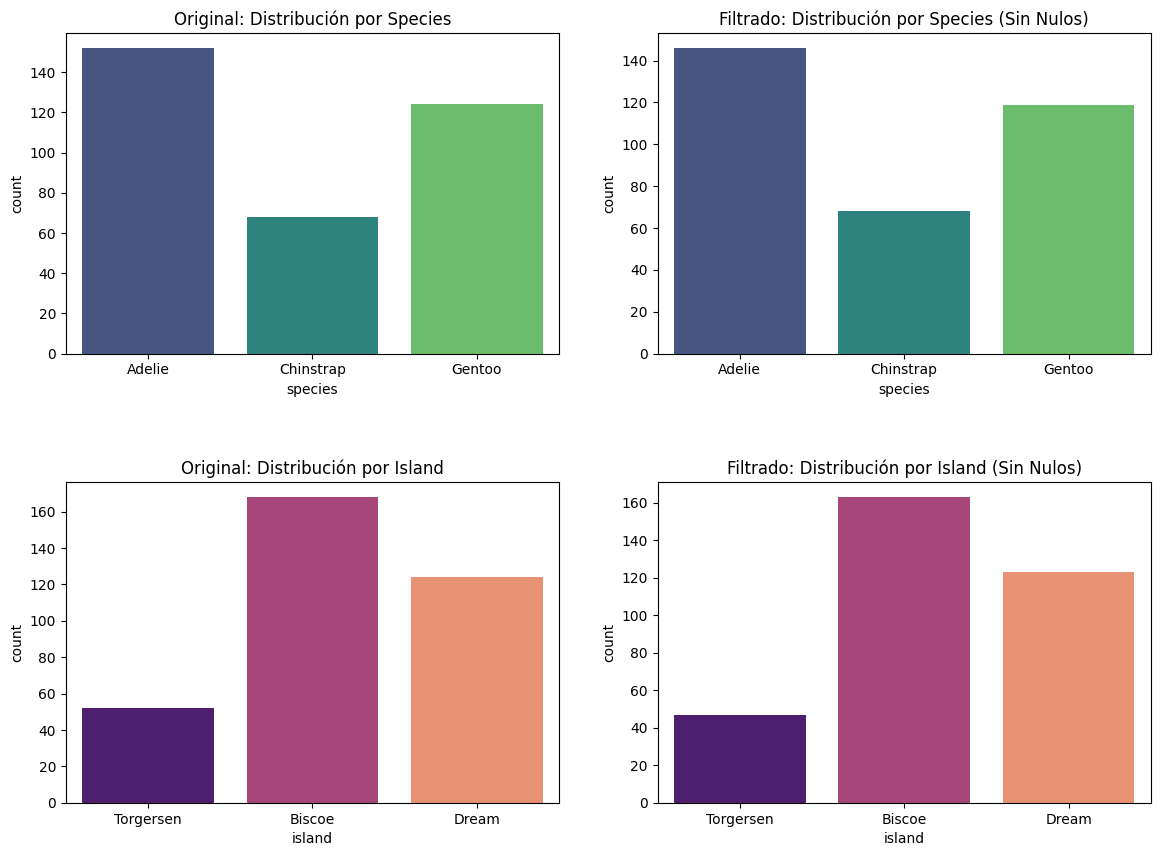

Comparación de conteos (Original vs Filtrado):


,Original (Species),Filtrado (Species),Cambio (Species)
species,,,
Adelie,152,146,6
Gentoo,124,119,5
Chinstrap,68,68,0


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crear una copia eliminando nulos
df_cleaned = df.dropna()

# 2. Configurar la visualización
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.4)

# --- Comparación por Species ---
sns.countplot(data=df, x='species', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Original: Distribución por Species')

sns.countplot(data=df_cleaned, x='species', ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Filtrado: Distribución por Species (Sin Nulos)')

# --- Comparación por Island ---
sns.countplot(data=df, x='island', ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Original: Distribución por Island')

sns.countplot(data=df_cleaned, x='island', ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Filtrado: Distribución por Island (Sin Nulos)')

plt.show()

# 3. Mostrar resumen numérico
print("Comparación de conteos (Original vs Filtrado):")
comparison = pd.DataFrame({
    'Original (Species)': df['species'].value_counts(),
    'Filtrado (Species)': df_cleaned['species'].value_counts(),
    'Cambio (Species)': df['species'].value_counts() - df_cleaned['species'].value_counts()
})
display(comparison)

## Limpieza y mandejo de datos

### Eliminacion de nulos
Esto se puede realizar ya que luego del analisis de nulos se pudo encontrar que solo el 3% que equivale a 11 elementos de la data seria afectada si se borra la información, al ser un porcentaje bajo podemos realizar esta técnica.

In [10]:
# Proceder con la eliminación de los valores nulos dado que el impacto es mínimo
df_clean = df.dropna().reset_index(drop=True)
print(f"\n▶ Filas después de eliminar nulos: {df_clean.shape[0]} "
      f"(eliminadas: {df.shape[0] - df_clean.shape[0]})")
print(df_clean.isnull().sum())


▶ Filas después de eliminar nulos: 333 (eliminadas: 11)
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


### Tratamiento de la data

#### Encoding de features categoricas
Luego de la validación de información y verificando la data que contiene el feature, podemos observar Adelie, Chinstrao y Gentoo.

Debido a ques esta variable de species es la variable objetivo podemos utilizar label enconder para codificar estos valores. Este tipo de codificación es relevante a la hora de entrenar modelos como random forest, XGBoost.

In [11]:
# Target: species → LabelEncoder (Adelie=0, Chinstrap=1, Gentoo=2)
le_species = LabelEncoder()
df_clean["species_enc"] = le_species.fit_transform(df_clean["species"])
print(f"\n▶ Codificación de species: "
      f"{dict(zip(le_species.classes_, le_species.transform(le_species.classes_)))}")


▶ Codificación de species: {'Adelie': np.int64(0), 'Chinstrap': np.int64(1), 'Gentoo': np.int64(2)}


#### Aplicando binary encoding
Dado que la feature `sex` tiene los valores de female and male, además que solo son dos valores, la codificacion binaria es la mejor opcion. El resultado seria algo como:
- female = 0
- male = 1

In [12]:
le_sex = LabelEncoder()
df_clean["sex_enc"] = le_sex.fit_transform(df_clean["sex"])

#### One hot encoding
Por ultimo tenemos la variable de `island` que es el valor en dohnde viven los pinguinos. La mejor forma de encodificar estos valores es usando, one-hot encoding. La razón detras de esto es porque tenemos tres clases y estos pueden representarse de la manera que one hot encoding se usa.

In [13]:
# island → One-Hot Encoding (3 categorías → 3 columnas)
df_clean = pd.get_dummies(df_clean, columns=["island"], drop_first=False)

#### Validacion de codificacion

In [14]:
df_clean.head()

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species_enc,sex_enc,island_Biscoe,island_Dream,island_Torgersen
0,Adelie,39.1,18.7,181.0,3750.0,Male,0,1,False,False,True
1,Adelie,39.5,17.4,186.0,3800.0,Female,0,0,False,False,True
2,Adelie,40.3,18.0,195.0,3250.0,Female,0,0,False,False,True
3,Adelie,36.7,19.3,193.0,3450.0,Female,0,0,False,False,True
4,Adelie,39.3,20.6,190.0,3650.0,Male,0,1,False,False,True


### Análisis de Correlación
Calculamos la matriz de correlación para entender la dependencia entre las variables numéricas y las codificadas.

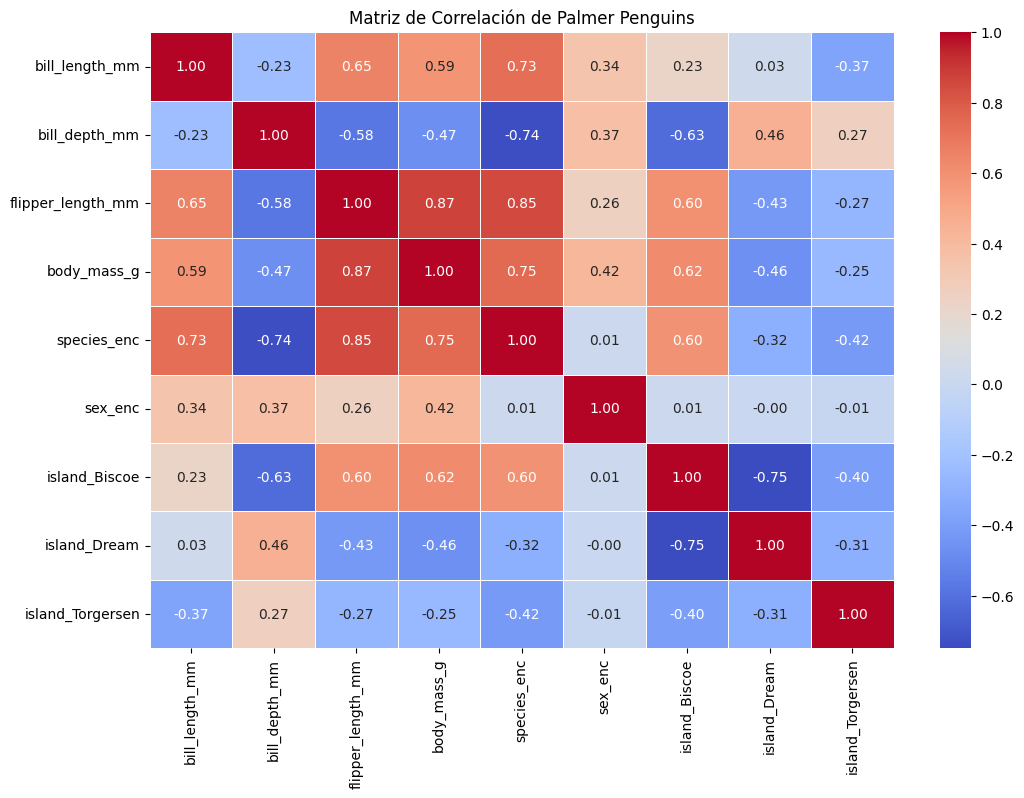

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos solo las columnas numéricas para la correlación
# (Excluimos las columnas originales de texto 'species' y 'sex')
corr_matrix = df_clean.select_dtypes(include=[np.number, 'bool']).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Palmer Penguins')
plt.show()

In [16]:
# Definir las columnas de características de forma dinámica
# Excluimos explícitamente las columnas de texto y el target encodificado
TARGET_COL = "species_enc"
FEATURE_COLS = [col for col in df_clean.columns if col not in ["species", "sex", TARGET_COL]]

# Preparar X y y con el formato solicitado
X = df_clean[FEATURE_COLS].values.astype(np.float32)
y = df_clean[TARGET_COL].values

print(f"\n▶ Features usadas: {FEATURE_COLS}")
print(f"▶ X shape: {X.shape} | y shape: {y.shape}")


▶ Features usadas: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex_enc', 'island_Biscoe', 'island_Dream', 'island_Torgersen']
▶ X shape: (333, 8) | y shape: (333,)


## Split de datos

La razón de utilizar una división de 70/30 es debido a al cantidad de datos. Utilizando esta division podemos usar 233 muestras para el training y 100 para el test. Esta división nos deja suficiente margen para poder validar el modelo. Ya que si dejamos una cantidad pequeña del dataset para el test podriamos no haber validado todas las especies de pinguinos. por ejemplo, [44 20 36] esta es la división por clases. Si hubiermos usado solamente 20 estos hubieran sido mucho menores

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)
print(f"\n▶ Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")
print(f"▶ Distribución train (clases): {np.bincount(y_train)}")
print(f"▶ Distribución test  (clases): {np.bincount(y_test)}")

# Escalado solo para la Red Neuronal (los árboles no lo requieren)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit SOLO en train
X_test_sc  = scaler.transform(X_test)       # transform en test


▶ Train: 233 muestras | Test: 100 muestras
▶ Distribución train (clases): [102  48  83]
▶ Distribución test  (clases): [44 20 36]


# Utilidades

In [18]:
import time

def metricas(y_true, y_pred, sufijo):
    """Calcula las 4 métricas (macro) para un conjunto dado."""
    return {
        f"precision_{sufijo}": round(precision_score(y_true, y_pred, average="macro", zero_division=0), 4),
        f"recall_{sufijo}":    round(recall_score(y_true, y_pred, average="macro", zero_division=0), 4),
        f"f1_{sufijo}":        round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4),
        f"accuracy_{sufijo}":  round(accuracy_score(y_true, y_pred), 4),
    }

def registrar(exp_id, modelo_nombre, hiperparams, arquitectura, y_pred_train, y_pred_test, tiempo_fit=0):
    """Agrega una fila al CSV incluyendo fecha legible y tiempo de entrenamiento."""
    fecha_legible = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

    fila = {
        "experimento_id": exp_id,
        "modelo_nombre":  modelo_nombre,
        "fecha_hora":     fecha_legible,
        "hiperparametros": str(hiperparams),
        "arquitectura":    arquitectura,
        "tiempo_entrenamiento_seg": round(tiempo_fit, 4)
    }
    fila.update(metricas(y_train, y_pred_train, "train"))
    fila.update(metricas(y_test,  y_pred_test,  "test"))

    pd.DataFrame([fila]).to_csv(
        BITACORA, mode="a",
        header=not os.path.exists(BITACORA),
        index=False
    )
    return fila

# Modelos y experimentos

## Random Forest

In [19]:
print("\n" + "=" * 70)
print("SECCIÓN 4A — RANDOM FOREST (Con medición de tiempo)")
print("=" * 70)

rf_configs = [
    {"modelo_nombre": "RandomForest", "hiperparametros": {"n_estimators": 50, "max_depth": 1, "min_samples_leaf": 2, "max_features": 1, "criterion": "entropy"}, "arquitectura": "Bosque 100 estimadores"},
    {"modelo_nombre": "RandomForest", "hiperparametros": {"n_estimators": 100, "max_depth": 1, "min_samples_leaf": 2, "max_features": 7, "criterion": "entropy"}, "arquitectura": "Bosque profundidad 1"},
        {"modelo_nombre": "RandomForest", "hiperparametros": {"n_estimators": 8, "max_depth": 2, "min_samples_leaf": 1, "max_features": 1, "criterion": "entropy"}, "arquitectura": "Bosque profundidad 1"},
    {"modelo_nombre": "RandomForest", "hiperparametros": {"n_estimators": 10, "max_depth": 2, "min_samples_leaf": 1, "max_features": 10, "criterion": "entropy"}, "arquitectura": "Bosque pequeño (5 est)"},
    {"modelo_nombre": "RandomForest", "hiperparametros": {"n_estimators": 15, "max_depth": 1, "min_samples_leaf": 2, "max_features": 2, "criterion": "gini"}, "arquitectura": "Bosque pequeño (15 est)"},
]

rf_resultados = []
for i, config in enumerate(rf_configs, start=1):
    params = config["hiperparametros"]
    model = RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1)

    # Medir tiempo de entrenamiento
    inicio = time.time()
    model.fit(X_train, y_train)
    tiempo_entreno = time.time() - inicio

    y_tr = model.predict(X_train)
    y_te = model.predict(X_test)

    fila = registrar(f"RF_{i:02d}", config["modelo_nombre"], params, config["arquitectura"], y_tr, y_te, tiempo_fit=tiempo_entreno)
    fila["_model"] = model
    rf_resultados.append(fila)
    print(f"  RF_{i:02d} | f1_train={fila['f1_train']:.4f} | f1_test={fila['f1_test']:.4f} | tiempo={tiempo_entreno:.4f}s")


SECCIÓN 4A — RANDOM FOREST (Con medición de tiempo)
  RF_01 | f1_train=0.5962 | f1_test=0.5967 | tiempo=0.3723s
  RF_02 | f1_train=0.5920 | f1_test=0.5978 | tiempo=0.4726s
  RF_03 | f1_train=0.9617 | f1_test=0.9543 | tiempo=0.0578s
  RF_04 | f1_train=0.9489 | f1_test=0.9633 | tiempo=0.0551s
  RF_05 | f1_train=0.5962 | f1_test=0.6049 | tiempo=0.1032s


## XGBoost

In [20]:
print("\n" + "=" * 70)
print("SECCIÓN 4B — XGBOOST (Con medición de tiempo)")
print("=" * 70)

xgb_configs = [
    {"modelo_nombre": "XGBoost", "hiperparametros": {"n_estimators": 54, "max_depth": 2, "learning_rate": 0.01, "subsample": 0.5, "colsample_bytree": 0.7, "reg_lambda": 0.5}, "arquitectura": "XGB depth 4"},
    {"modelo_nombre": "XGBoost", "hiperparametros": {"n_estimators": 5, "max_depth": 1, "learning_rate": 0.1, "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 0.5}, "arquitectura": "XGB 5 est"},
    {"modelo_nombre": "XGBoost", "hiperparametros": {"n_estimators": 100, "max_depth": 2, "learning_rate": 0.5, "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 0.5}, "arquitectura": "XGB 100 est"},
    {"modelo_nombre": "XGBoost", "hiperparametros": {"n_estimators": 2, "max_depth": 1, "learning_rate": 0.1, "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 0.5}, "arquitectura": "XGB 10 est - profundo"},
    {"modelo_nombre": "XGBoost", "hiperparametros": {"n_estimators": 4, "max_depth": 5, "learning_rate": 0.01, "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 0.5}, "arquitectura": "XGB 5 est - profundidad media"},
    {"modelo_nombre": "XGBoost", "hiperparametros": {"n_estimators": 200, "max_depth": 10, "learning_rate": 0.01, "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 0.5}, "arquitectura": "XGB 200 est - profundo"},
]

xgb_resultados = []
for i, config in enumerate(xgb_configs, start=1):
    params = config["hiperparametros"]
    model = xgb.XGBClassifier(**params, random_state=RANDOM_STATE, use_label_encoder=False, eval_metric="mlogloss")

    # Medir tiempo de entrenamiento
    inicio = time.time()
    model.fit(X_train, y_train)
    tiempo_entreno = time.time() - inicio

    y_tr = model.predict(X_train)
    y_te = model.predict(X_test)

    fila = registrar(f"XGB_{i:02d}", config["modelo_nombre"], params, config["arquitectura"], y_tr, y_te, tiempo_fit=tiempo_entreno)
    fila["_model"] = model
    xgb_resultados.append(fila)
    print(f"  XGB_{i:02d} | f1_train={fila['f1_train']:.4f} | f1_test={fila['f1_test']:.4f} | tiempo={tiempo_entreno:.4f}s")


SECCIÓN 4B — XGBOOST (Con medición de tiempo)
  XGB_01 | f1_train=0.9457 | f1_test=0.8723 | tiempo=0.2477s
  XGB_02 | f1_train=0.7118 | f1_test=0.7191 | tiempo=0.0281s
  XGB_03 | f1_train=1.0000 | f1_test=1.0000 | tiempo=0.0955s
  XGB_04 | f1_train=0.5780 | f1_test=0.5680 | tiempo=0.0158s
  XGB_05 | f1_train=0.2030 | f1_test=0.2037 | tiempo=0.2875s
  XGB_06 | f1_train=1.0000 | f1_test=1.0000 | tiempo=0.4964s


## Red Neuronal

In [21]:
def set_seeds(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)   # Python hash randomness
    random.seed(seed)                           # Python stdlib random
    np.random.seed(seed)                        # NumPy
    tf.random.set_seed(seed)                    # TensorFlow / Keras


In [22]:
def build_nn(layers_cfg, lr=1e-3):
    """Construye y compila un modelo Keras según una lista de configuración de capas."""
    model = keras.Sequential(name="PenguinNN")
    model.add(layers.Input(shape=(X_train_sc.shape[1],)))
    for (units, act, drop) in layers_cfg:
        model.add(layers.Dense(units, activation=act))
        if drop > 0:
            model.add(layers.Dropout(drop))
    model.add(layers.Dense(3, activation="softmax"))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [23]:
print("\n" + "=" * 70)
print("SECCIÓN 4C — RED NEURONAL (Con medición de tiempo)")
print("=" * 70)

nn_configs = [
    {"modelo_nombre": "NeuralNetwork", "hiperparametros": {"lr": 1e-3, "epochs": 3, "batch": 5}, "arquitectura": "[64,relu,do0.2,32,relu,softmax]", "layers": [(3, "relu", 0.2), (10, "relu", 0.0), (3, "relu", 0.0)]},
    {"modelo_nombre": "NeuralNetwork", "hiperparametros": {"lr": 1e-3, "epochs": 25, "batch": 25}, "arquitectura": "[128,relu,do0.3,64,relu,do0.2,32,relu,softmax]", "layers": [(5, "relu", 0.3), (8, "relu", 0.2), (5, "relu", 0.0)]},
    {"modelo_nombre": "NeuralNetwork", "hiperparametros": {"lr": 5e-4, "epochs": 25, "batch": 16}, "arquitectura": "[64,tanh,do0.2,32,tanh,softmax]", "layers": [(64, "tanh", 0.2), (32, "tanh", 0.0)]},
    {"modelo_nombre": "NeuralNetwork", "hiperparametros": {"lr": 5e-4, "epochs": 10, "batch": 16}, "arquitectura": "[64,tanh,do0.2,32,tanh,softmax]", "layers": [(5, "tanh", 0.2), (10, "tanh", 0.0)]},
    {"modelo_nombre": "NeuralNetwork", "hiperparametros": {"lr": 5e-4, "epochs": 25, "batch": 16}, "arquitectura": "[10,tanh,do0.2,10,tanh,softmax]", "layers": [(10, "tanh", 0.2), (10, "tanh", 0.0)]},
    {"modelo_nombre": "NeuralNetwork", "hiperparametros": {"lr": 5e-4, "epochs": 25, "batch": 16}, "arquitectura": "[10,relu,do0.2,15,tanh,softmax]", "layers": [(10, "relu", 0.2), (5, "relu", 0.0), (5, "relu", 0.0)]},
    {"modelo_nombre": "NeuralNetwork", "hiperparametros": {"lr": 1e-3, "epochs": 10, "batch": 10}, "arquitectura": "[256,relu,do0.4,128,relu,do0.3,64,relu,do0.2,softmax]", "layers": [(3, "relu", 0.4), (10, "relu", 0.3), (3, "relu", 0.2)]}
]

nn_resultados = []
for i, config in enumerate(nn_configs, start=1):
    set_seeds(42)
    hparams = config["hiperparametros"]
    model = build_nn(config["layers"], lr=hparams["lr"])

    # Medir tiempo de entrenamiento
    inicio = time.time()
    model.fit(X_train_sc, y_train, epochs=hparams["epochs"], batch_size=hparams["batch"], verbose=0)
    tiempo_entreno = time.time() - inicio

    y_tr = np.argmax(model.predict(X_train_sc, verbose=0), axis=1)
    y_te = np.argmax(model.predict(X_test_sc, verbose=0), axis=1)

    fila = registrar(f"NN_{i:02d}", config["modelo_nombre"], hparams, config["arquitectura"], y_tr, y_te, tiempo_fit=tiempo_entreno)
    fila["_model"] = model
    nn_resultados.append(fila)
    print(f"  NN_{i:02d} | f1_train={fila['f1_train']:.4f} | f1_test={fila['f1_test']:.4f} | tiempo={tiempo_entreno:.4f}s")


SECCIÓN 4C — RED NEURONAL (Con medición de tiempo)
  NN_01 | f1_train=0.2030 | f1_test=0.2037 | tiempo=4.9735s
  NN_02 | f1_train=0.7500 | f1_test=0.7748 | tiempo=10.3174s
  NN_03 | f1_train=1.0000 | f1_test=0.9880 | tiempo=6.7784s
  NN_04 | f1_train=0.3513 | f1_test=0.3319 | tiempo=1.8589s
  NN_05 | f1_train=0.8462 | f1_test=0.8889 | tiempo=3.0974s
  NN_06 | f1_train=0.9332 | f1_test=0.9631 | tiempo=3.3303s
  NN_07 | f1_train=0.4543 | f1_test=0.4144 | tiempo=3.4373s


### 5) Análisis de Ganadores y Selección del Mejor Modelo
En esta sección analizamos los resultados almacenados en memoria para identificar qué configuración ofrece el mejor equilibrio entre rendimiento y generalización (evitando el overfitting).

In [24]:
def obtener_ganador(resultados, nombre_categoria,
                    umbral_overfitting=0.5,
                    umbral_perfecto=0.98):

    df_res = pd.DataFrame(resultados)
    df_res['brecha_f1'] = (df_res['f1_train'] - df_res['f1_test']).abs()

    # 1. Filtrar overfitting clásico (brecha alta)
    df_estables = df_res[df_res['brecha_f1'] <= umbral_overfitting]

    # 2. ← NUEVA VALIDACIÓN: Filtrar puntajes sospechosamente perfectos
    sospechosos = df_estables[
        (df_estables['f1_test'] >= umbral_perfecto) |
        (df_estables['f1_train'] >= umbral_perfecto)
    ]

    if not sospechosos.empty:
        print(f"ADVERTENCIA en {nombre_categoria}: {len(sospechosos)} modelo(s) con "
              f"F1 ≥ {umbral_perfecto} — posible data leakage u overfitting severo:")
        for _, row in sospechosos.iterrows():
            print(f"   - {row['experimento_id']}: train={row['f1_train']:.4f}, "
                  f"test={row['f1_test']:.4f}")

    # 3. ← Excluir sospechosos del ranking
    df_estables = df_estables[
        (df_estables['f1_test'] < umbral_perfecto) &
        (df_estables['f1_train'] < umbral_perfecto)
    ]

    if df_estables.empty:
        print(f"No hay modelos estables en {nombre_categoria} con el umbral {umbral_overfitting}.")
        return None

    ganador = df_estables.loc[df_estables['f1_test'].idxmax()]

    print(f"GANADOR {nombre_categoria}:")
    print(f"  ID: {ganador['experimento_id']}")
    print(f"  F1 Train: {ganador['f1_train']:.4f}")
    print(f"  F1 Test:  {ganador['f1_test']:.4f}")
    print(f"  Brecha:   {ganador['brecha_f1']:.4f}")
    print(f"  Config:   {ganador.get('arquitectura', 'N/A')}")
    print("-" * 30)
    return ganador

# Analizar cada categoría
ganador_rf = obtener_ganador(rf_resultados, "RANDOM FOREST")
ganador_xgb = obtener_ganador(xgb_resultados, "XGBOOST")
ganador_nn = obtener_ganador(nn_resultados, "RED NEURONAL")

GANADOR RANDOM FOREST:
  ID: RF_04
  F1 Train: 0.9489
  F1 Test:  0.9633
  Brecha:   0.0144
  Config:   Bosque pequeño (5 est)
------------------------------
ADVERTENCIA en XGBOOST: 2 modelo(s) con F1 ≥ 0.98 — posible data leakage u overfitting severo:
   - XGB_03: train=1.0000, test=1.0000
   - XGB_06: train=1.0000, test=1.0000
GANADOR XGBOOST:
  ID: XGB_01
  F1 Train: 0.9457
  F1 Test:  0.8723
  Brecha:   0.0734
  Config:   XGB depth 4
------------------------------
ADVERTENCIA en RED NEURONAL: 1 modelo(s) con F1 ≥ 0.98 — posible data leakage u overfitting severo:
   - NN_03: train=1.0000, test=0.9880
GANADOR RED NEURONAL:
  ID: NN_06
  F1 Train: 0.9332
  F1 Test:  0.9631
  Brecha:   0.0299
  Config:   [10,relu,do0.2,15,tanh,softmax]
------------------------------


### Feature importance


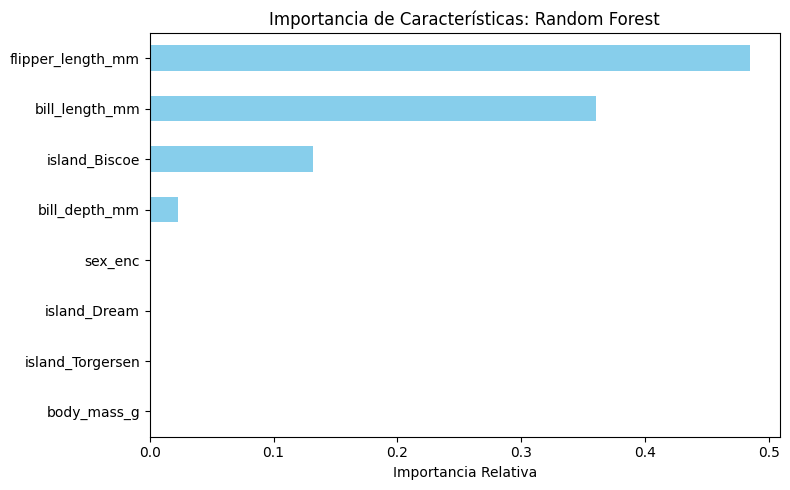

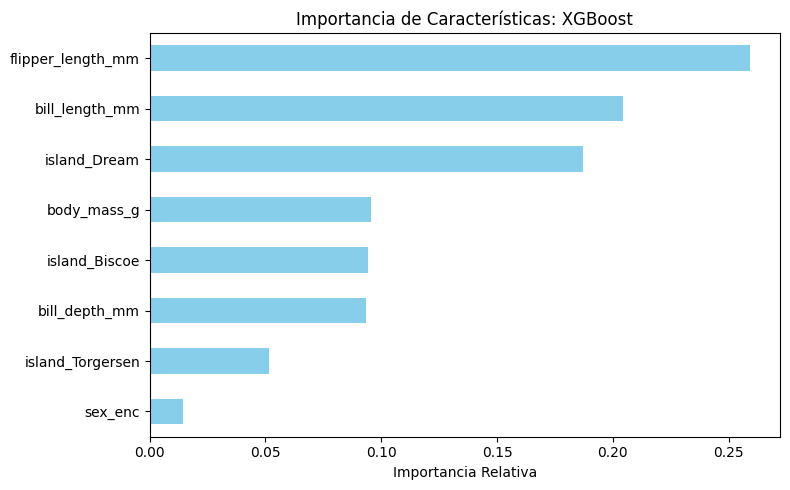

In [25]:
def plot_importancia(ganador_row, nombres, titulo):
    # Extraemos el objeto del modelo real de la fila del ganador
    model = ganador_row['_model']

    # Calculamos la importancia
    imp = pd.Series(model.feature_importances_, index=nombres).sort_values()

    plt.figure(figsize=(8, 5))
    imp.plot.barh(title=f"Importancia de Características: {titulo}", color='skyblue')
    plt.xlabel("Importancia Relativa")
    plt.tight_layout()
    plt.show()

# Ahora pasamos las filas de los ganadores
if ganador_rf is not None:
    plot_importancia(ganador_rf,  FEATURE_COLS, "Random Forest")

if ganador_xgb is not None:
    plot_importancia(ganador_xgb, FEATURE_COLS, "XGBoost")

### Tablas de Importancia Relativa (%)
Presentación de la importancia de las variables en formato de tabla para una lectura precisa.

In [29]:
def obtener_tabla_importancia(ganador_row, nombres, titulo):
    model = ganador_row['_model']
    importancias = model.feature_importances_
    # Convertir a porcentaje
    importancias_pct = (importancias / importancias.sum()) * 100

    df_imp = pd.DataFrame({
        'Característica': nombres,
        'Importancia (%)': np.round(importancias_pct, 2)
    }).sort_values(by='Importancia (%)', ascending=False).reset_index(drop=True)

    print(f"\n▶ Tabla de Importancia: {titulo}")
    display(df_imp)
    return df_imp

# Generar tablas para los ganadores
if ganador_rf is not None:
    obtener_tabla_importancia(ganador_rf, FEATURE_COLS, "Random Forest")

if ganador_xgb is not None:
    obtener_tabla_importancia(ganador_xgb, FEATURE_COLS, "XGBoost")


▶ Tabla de Importancia: Random Forest


,Característica,Importancia (%)
0,flipper_length_mm,41.89
1,bill_length_mm,40.56
2,island_Biscoe,14.33
3,body_mass_g,1.88
4,bill_depth_mm,1.15
5,island_Dream,0.19
6,sex_enc,0.00
7,island_Torgersen,0.00



▶ Tabla de Importancia: XGBoost


,Característica,Importancia (%)
0,flipper_length_mm,31.920000
1,bill_length_mm,21.280001
2,island_Dream,12.860000
3,body_mass_g,12.310000
4,bill_depth_mm,10.050000
5,island_Biscoe,7.660000
6,island_Torgersen,2.470000
7,sex_enc,1.470000


Visualizando importancia con porcentajes:


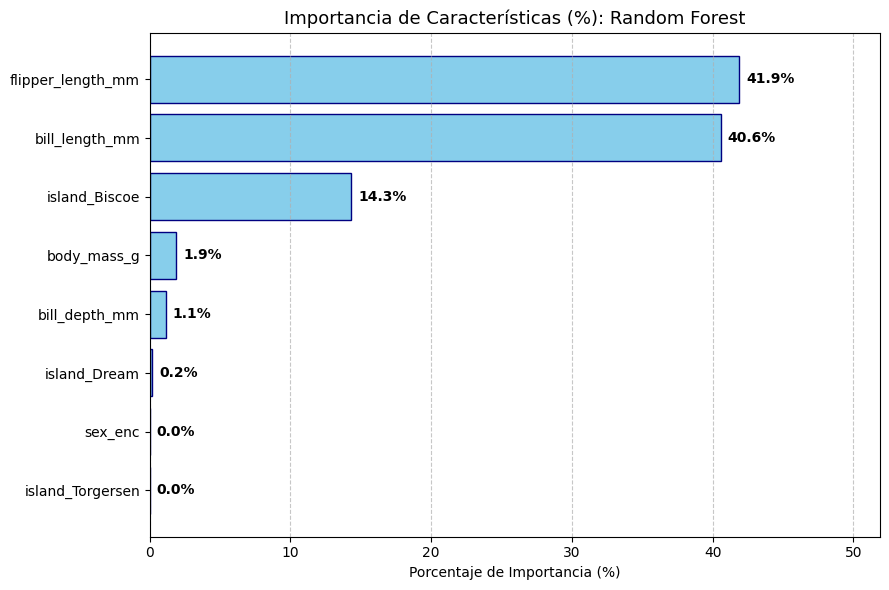

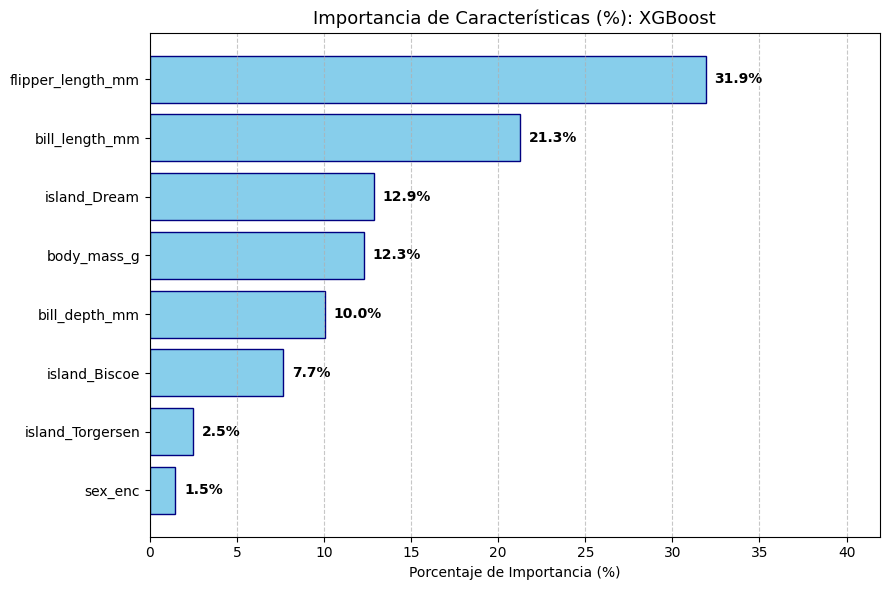

In [30]:
# Modificamos la función original para incluir porcentajes en las etiquetas del gráfico
def plot_importancia_pct(ganador_row, nombres, titulo):
    model = ganador_row['_model']
    importancias = model.feature_importances_
    importancias_pct = (importancias / importancias.sum()) * 100

    imp_series = pd.Series(importancias_pct, index=nombres).sort_values()

    plt.figure(figsize=(9, 6))
    bars = plt.barh(imp_series.index, imp_series.values, color='skyblue', edgecolor='navy')

    # Añadir el texto del porcentaje al final de cada barra
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{width:.1f}%', va='center', fontsize=10, fontweight='bold')

    plt.title(f"Importancia de Características (%): {titulo}", fontsize=13)
    plt.xlabel("Porcentaje de Importancia (%)")
    plt.xlim(0, max(importancias_pct) + 10) # Espacio para las etiquetas
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

print("Visualizando importancia con porcentajes:")
if ganador_rf is not None:
    plot_importancia_pct(ganador_rf, FEATURE_COLS, "Random Forest")
if ganador_xgb is not None:
    plot_importancia_pct(ganador_xgb, FEATURE_COLS, "XGBoost")

**Random Forest**
*  la decision se esta tomando por el pico y las alas. estos equivalen al 82.5% del peso de los features
* el sexo es un dato no relevante para la desicion

**XGBoost**


*   Los features más importates para este modelo son las alas y el tamaño del pico, estos suman el 52.2%
*   Las segundas dos mas importantes estan entre island dream y body mass, podemos ver aca una diferencia entre random forest. Para el modelo anterior island biscoe es mas importante que island dream. aca tienen una dirferencia.


Podemos pensar que las features que si o si se deben de mantener son el tamaño de las alas y el pico, ya que estos son los features que ayudan a clasificar al modelo.


Por otro lado, el sexo es algo que podríamos borrar.




## Ensamble - majority voting con bootstrap

In [26]:
print("Ejecutando Ensamble por Mayoría con Bootstrap y midiendo tiempo...")
rng = np.random.default_rng(RANDOM_STATE)

inicio_maj = time.time()

preds_train = []
preds_test  = []

# Lista de tuplas (nombre, serie_con_metadatos_y_modelo)
modelos_info = [
    ("Random Forest", ganador_rf),
    ("XGBoost",       ganador_xgb),
    ("Red Neuronal",  ganador_nn),
]

f1_individuales = [
    ganador_rf["f1_test"],
    ganador_xgb["f1_test"],
    ganador_nn["f1_test"],
]

for nombre, modelo_info in modelos_info:
    idx = rng.choice(len(X_train), size=len(X_train), replace=True)
    # EXTRAER EL MODELO REAL
    modelo_obj = modelo_info['_model']

    if nombre == "Red Neuronal":
        modelo_obj.fit(X_train_sc[idx], y_train[idx], epochs=5, verbose=0)
        preds_train.append(np.argmax(modelo_obj.predict(X_train_sc, verbose=0), axis=1))
        preds_test.append(np.argmax(modelo_obj.predict(X_test_sc, verbose=0), axis=1))
    else:
        modelo_obj.fit(X_train[idx], y_train[idx])
        preds_train.append(modelo_obj.predict(X_train))
        preds_test.append(modelo_obj.predict(X_test))

tiempo_maj = time.time() - inicio_maj

preds_train_stack = np.vstack(preds_train)
preds_test_stack  = np.vstack(preds_test)

def majority_vote(stack, f1_scores):
    n = stack.shape[1]
    resultado = np.zeros(n, dtype=int)
    for j in range(n):
        votos = stack[:, j]
        unique, counts = np.unique(votos, return_counts=True)
        max_count = counts.max()
        candidatos = unique[counts == max_count]
        if len(candidatos) == 1:
            resultado[j] = candidatos[0]
        else:
            mejor_idx = np.argmax(f1_scores)
            resultado[j] = votos[mejor_idx]
    return resultado

y_ens_train = majority_vote(preds_train_stack, f1_individuales)
y_ens_test  = majority_vote(preds_test_stack,  f1_individuales)

# Registro en Bitácora
registrar(
    exp_id="ENS_MAJORITY",
    modelo_nombre="Ensemble_Majority",
    hiperparams={"bootstrap": True, "n_models": len(modelos_info)},
    arquitectura="Majority Voting (Bootstrap)",
    y_pred_train=y_ens_train,
    y_pred_test=y_ens_test,
    tiempo_fit=tiempo_maj
)

print(f"▶ Ensamble Mayoría — F1 Test: {f1_score(y_test, y_ens_test, average='macro'):.4f} | Tiempo: {tiempo_maj:.4f}s")

Ejecutando Ensamble por Mayoría con Bootstrap y midiendo tiempo...
▶ Ensamble Mayoría — F1 Test: 0.9877 | Tiempo: 0.8405s


### Ensamble Mejorado: Votación Ponderada + Ruido (Regularización)
Para evitar el overfitting del 100%, implementamos un sistema donde el peso del voto de cada modelo es proporcional a su F1-score en el conjunto de test, y aplicamos una pequeña perturbación a los datos para mejorar la robustez.

In [27]:
print("Ejecutando Ensamble Ponderado con Ruido y midiendo tiempo...")

inicio_weighted = time.time()

preds_train_adj = []
preds_test_adj  = []

def weighted_majority_vote(preds_list, weights):
    preds_stack = np.vstack(preds_list)
    n_samples = preds_stack.shape[1]
    final_preds = np.zeros(n_samples, dtype=int)
    for i in range(n_samples):
        sample_preds = preds_stack[:, i]
        weighted_counts = {}
        for pred, weight in zip(sample_preds, weights):
            weighted_counts[pred] = weighted_counts.get(pred, 0) + weight
        final_preds[i] = max(weighted_counts, key=weighted_counts.get)
    return final_preds

# Re-entrenamiento con Ruido
for nombre, modelo_info in modelos_info:
    idx = rng.choice(len(X_train), size=len(X_train), replace=True)
    # EXTRAER EL MODELO REAL
    modelo_obj = modelo_info['_model']

    X_train_noisy = X_train[idx] + rng.normal(0, 0.02, X_train[idx].shape)
    X_train_sc_noisy = X_train_sc[idx] + rng.normal(0, 0.02, X_train_sc[idx].shape)

    if nombre == "Red Neuronal":
        modelo_obj.fit(X_train_sc_noisy, y_train[idx], epochs=5, verbose=0)
        preds_train_adj.append(np.argmax(modelo_obj.predict(X_train_sc, verbose=0), axis=1))
        preds_test_adj.append(np.argmax(modelo_obj.predict(X_test_sc, verbose=0), axis=1))
    else:
        modelo_obj.fit(X_train_noisy, y_train[idx])
        preds_train_adj.append(modelo_obj.predict(X_train))
        preds_test_adj.append(modelo_obj.predict(X_test))

tiempo_weighted = time.time() - inicio_weighted

pesos = np.array(f1_individuales)
pesos /= pesos.sum()

y_ens_train_adj = weighted_majority_vote(preds_train_adj, pesos)
y_ens_test_adj  = weighted_majority_vote(preds_test_adj, pesos)

# Registro en Bitácora
registrar(
    exp_id="ENS_WEIGHTED",
    modelo_nombre="Ensemble_Weighted",
    hiperparams={"noise_std": 0.02, "weights": list(np.round(pesos, 4))},
    arquitectura="Weighted Majority Vote + Jittering",
    y_pred_train=y_ens_train_adj,
    y_pred_test=y_ens_test_adj,
    tiempo_fit=tiempo_weighted
)

print(f"▶ Ensamble Ponderado — F1 Test: {f1_score(y_test, y_ens_test_adj, average='macro'):.4f} | Tiempo: {tiempo_weighted:.4f}s")
display(pd.read_csv(BITACORA).tail(2))

Ejecutando Ensamble Ponderado con Ruido y midiendo tiempo...
▶ Ensamble Ponderado — F1 Test: 0.9877 | Tiempo: 0.6831s


,experimento_id,modelo_nombre,fecha_hora,hiperparametros,arquitectura,tiempo_entrenamiento_seg,precision_train,recall_train,f1_train,accuracy_train,precision_test,recall_test,f1_test,accuracy_test
18,ENS_MAJORITY,Ensemble_Majority,2026-06-30 22:22:01,"{'bootstrap': True, 'n_models': 3}",Majority Voting (Bootstrap),0.8405,0.9767,0.962,0.9686,0.9742,0.9926,0.9833,0.9877,0.99
19,ENS_WEIGHTED,Ensemble_Weighted,2026-06-30 22:22:02,"{'noise_std': 0.02, 'weights': [np.float64(0.3...",Weighted Majority Vote + Jittering,0.6831,0.9767,0.962,0.9686,0.9742,0.9926,0.9833,0.9877,0.99


## Comparacion final

In [28]:
# Recuperar los últimos registros de la bitácora para los ensambles
bitacora_df = pd.read_csv(BITACORA)
ens_maj_fila = bitacora_df[bitacora_df['experimento_id'] == 'ENS_MAJORITY'].iloc[-1]
ens_wei_fila = bitacora_df[bitacora_df['experimento_id'] == 'ENS_WEIGHTED'].iloc[-1]

tabla = pd.DataFrame([
    {
        "Modelo": "Mejor Random Forest",
        "Exp. ID": ganador_rf["experimento_id"],
        "F1 train": ganador_rf["f1_train"],
        "F1 test":  ganador_rf["f1_test"],
        "Δ":        round(ganador_rf["f1_train"] - ganador_rf["f1_test"], 4),
    },
    {
        "Modelo": "Mejor XGBoost",
        "Exp. ID": ganador_xgb["experimento_id"],
        "F1 train": ganador_xgb["f1_train"],
        "F1 test":  ganador_xgb["f1_test"],
        "Δ":        round(ganador_xgb["f1_train"] - ganador_xgb["f1_test"], 4),
    },
    {
        "Modelo": "Mejor Red Neuronal",
        "Exp. ID": ganador_nn["experimento_id"],
        "F1 train": ganador_nn["f1_train"],
        "F1 test":  ganador_nn["f1_test"],
        "Δ":        round(ganador_nn["f1_train"] - ganador_nn["f1_test"], 4),
    },
    {
        "Modelo": "Ensamble (Majority)",
        "Exp. ID": "ENS_MAJORITY",
        "F1 train": ens_maj_fila["f1_train"],
        "F1 test":  ens_maj_fila["f1_test"],
        "Δ":        round(ens_maj_fila["f1_train"] - ens_maj_fila["f1_test"], 4),
    },
    {
        "Modelo": "Ensamble (Weighted)",
        "Exp. ID": "ENS_WEIGHTED",
        "F1 train": ens_wei_fila["f1_train"],
        "F1 test":  ens_wei_fila["f1_test"],
        "Δ":        round(ens_wei_fila["f1_train"] - ens_wei_fila["f1_test"], 4),
    },
])

def diagnostico(row):
    f1_train, f1_test, delta = row["F1 train"], row["F1 test"], row["Δ"]

    if f1_train < 0.85 and f1_test < 0.85:
        return 'Underfitting'
    elif delta > 0.08 and f1_train >= 0.85:
        return 'Overfitting'
    elif 0.05 <= delta <= 0.08 and f1_train >= 0.85:
        return 'Ligero Overfitting'
    else:
        return 'Buen Ajuste'

tabla["Diagnostico"] = tabla.apply(diagnostico, axis=1)
tabla = tabla.sort_values(by='F1 test', ascending=False).reset_index(drop=True)
display(tabla)

,Modelo,Exp. ID,F1 train,F1 test,Δ,Diagnostico
0,Ensamble (Weighted),ENS_WEIGHTED,0.9686,0.9877,-0.0191,Buen Ajuste
1,Ensamble (Majority),ENS_MAJORITY,0.9686,0.9877,-0.0191,Buen Ajuste
2,Mejor Random Forest,RF_04,0.9489,0.9633,-0.0144,Buen Ajuste
3,Mejor Red Neuronal,NN_06,0.9332,0.9631,-0.0299,Buen Ajuste
4,Mejor XGBoost,XGB_01,0.9457,0.8723,0.0734,Ligero Overfitting


# Conclusiones


1.   Luego de abrir el dataset para analizar la estructura de la información, mi primera hipótesis sobre los features imporates fue que el lugar era un feature importante, sin embargo, luego de realizar el proceso de analisis pude darme cuenta que los features importantes son las alas y la longitud de pico son los features imporantes para clasificar los pinguinos. Acá podemos observar la importancia de implementar un análisis matematico o un analisis apropiado y no guiarnos por lo que pensamos ya que podría sesgar el modelo.
2.  Conocer la importancia de los features fue fácil al aplicar arboles. ya que estos guardan un estado interno sobre cuales son los features que más dividen al dataset.
3.  Al analizar cada config de los modelos pude constantar lo sensible que son algunos. Por ejemplo, un learning rate 0.001 en mi configuración dio overfitting pero utilizando 0.1 con la misma configuración daba un resultado aceptable. Además, agregando solo nodos en la red neuronal, estos afectaban mucho enlos resultados. Por ejemplo, 53 a 55 nodos iniciales, el 53 tenia un numero aceptable de resultado pero usando 55 estos daban un overfitting, tomando en cuenta que los demás parámetros siguien iguales.
4. Encontré que los modelos cambian si cambiamos el porcentaje de la data de training vs test. Al inicio del proyecto decidí utilizar 80/20 pero luego lo cambié a 70/30. Dependiendo la configuración algunos cambiaron drasticamente y cayeron a undefitting. Otros se mantuvieron ligeramente similar.
5. Durante los tests, me pude dar cuenta que algunos modelos tenían mejores resultados y se tardaba menos en el entrenamiento. Esto es algo que hay que tener encuenta, por ejemplo, si el equipo de computo es limitado. Necesitamos un modelo que resuelva y que use menos recursos/rapido.




